# Eurovision analytics

In [1]:
import pandas as pd
import os

In [2]:
files = [file for file in os.listdir("./eurovision_data")]

eurovision_data = pd.DataFrame()

for file in files:
    df = pd.read_csv("./eurovision_data/"+file)
    eurovision_data = pd.concat([eurovision_data, df])
    
eurovision_data.to_csv("eurovision_data.csv", index=False)

### Please refer here:
https://stackoverflow.com/questions/3207219/how-do-i-list-all-files-of-a-directory

This will allow us to read all files in the directory.

### Please also refer here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html

This will allow us to join the datasheets that we've just read.

In [3]:
eurovisiondata = pd.read_csv("eurovision_data.csv")
eurovisiondata

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate
0,1975,f,1975f,J,Belgium,Belgium,0,x
1,1975,f,1975f,J,Belgium,Finland,0,NaN
2,1975,f,1975f,J,Belgium,France,2,NaN
3,1975,f,1975f,J,Belgium,Germany,0,NaN
4,1975,f,1975f,J,Belgium,Ireland,12,NaN
...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,NaN
49828,2019,f,2019f,J,Belarus,Germany,8,NaN
49829,2019,f,2019f,J,Belarus,Belarus,0,x
49830,2019,f,2019f,J,Belarus,The Netherlands,0,NaN


We need to add some content to the dataframe before we answer questions. First, let's list out the columns that we have.

In [4]:
eurovisiondata.columns

Index(['Year', '(semi-) final', 'Edition', 'Jury or Televoting',
       'From country', 'To country', 'Points      ', 'Duplicate'],
      dtype='object')

We see that the 'Points' column name has blank spaces that needs to be removed. In order to do that, do:

In [5]:
eurovisiondata.columns = eurovisiondata.columns.str.strip()
eurovisiondata.columns

Index(['Year', '(semi-) final', 'Edition', 'Jury or Televoting',
       'From country', 'To country', 'Points', 'Duplicate'],
      dtype='object')

We need to add two more columns: 'Decade' and 'Century'.

In [6]:
eurovisiondata = eurovisiondata.astype(str)

In [7]:
eurovisiondata['Decade'] = eurovisiondata['Year'].str[0:3]+'0'
eurovisiondata

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate,Decade
0,1975,f,1975f,J,Belgium,Belgium,0,x,1970
1,1975,f,1975f,J,Belgium,Finland,0,nan,1970
2,1975,f,1975f,J,Belgium,France,2,nan,1970
3,1975,f,1975f,J,Belgium,Germany,0,nan,1970
4,1975,f,1975f,J,Belgium,Ireland,12,nan,1970
...,...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,nan,2010
49828,2019,f,2019f,J,Belarus,Germany,8,nan,2010
49829,2019,f,2019f,J,Belarus,Belarus,0,x,2010
49830,2019,f,2019f,J,Belarus,The Netherlands,0,nan,2010


In [8]:
eurovisiondata['Century'] = eurovisiondata['Year'].str[0:2]+'00'
eurovisiondata

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate,Decade,Century
0,1975,f,1975f,J,Belgium,Belgium,0,x,1970,1900
1,1975,f,1975f,J,Belgium,Finland,0,nan,1970,1900
2,1975,f,1975f,J,Belgium,France,2,nan,1970,1900
3,1975,f,1975f,J,Belgium,Germany,0,nan,1970,1900
4,1975,f,1975f,J,Belgium,Ireland,12,nan,1970,1900
...,...,...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,nan,2010,2000
49828,2019,f,2019f,J,Belarus,Germany,8,nan,2010,2000
49829,2019,f,2019f,J,Belarus,Belarus,0,x,2010,2000
49830,2019,f,2019f,J,Belarus,The Netherlands,0,nan,2010,2000


Just in case, are all the country names consistent over time?

In [9]:
eurovisiondata['From country'].unique()

array(['Belgium', 'Finland', 'France', 'Germany', 'Ireland', 'Israel',
       'Italy', 'Luxembourg', 'Malta', 'Monaco', 'Norway', 'Portugal',
       'Spain', 'Sweden', 'Switzerland', 'The Netherlands', 'Turkey',
       'United Kingdom', 'Yugoslavia', 'Austria', 'Greece', 'Denmark',
       'Morocco', 'Cyprus', 'Iceland', 'Bosnia & Herzegovina', 'Croatia',
       'Slovenia', 'Estonia', 'Hungary', 'Lithuania', 'Poland', 'Romania',
       'Russia', 'Slovakia', 'F.Y.R. Macedonia', 'Latvia', 'Ukraine',
       'Albania', 'Andorra', 'Belarus', 'Serbia & Montenegro', 'Bulgaria',
       'Moldova', 'Armenia', 'Czech Republic', 'Georgia', 'Montenegro',
       'Serbia', 'Azerbaijan', 'San Marino', 'Australia', 'Macedonia',
       'The Netherands', 'North Macedonia'], dtype=object)

This shows there the dataframe has three entries for Macedonia: 'F.Y.R. Macedonia', 'Macedonia', and 'North Macedonia'. We also see a spelling error that gave us 'The Netherlands' and 'The Netherands', so we have to change that as well. Let's see if this is the case for 'To country as well':

In [10]:
eurovisiondata['To country'].unique()

array(['Belgium', 'Finland', 'France', 'Germany', 'Ireland', 'Israel',
       'Italy', 'Luxembourg', 'Malta', 'Monaco', 'Norway', 'Portugal',
       'Spain', 'Sweden', 'Switzerland', 'The Netherlands', 'Turkey',
       'United Kingdom', 'Yugoslavia', 'Austria', 'Greece', 'Denmark',
       'Morocco', 'Cyprus', 'Iceland', 'Bosnia & Herzegovina', 'Croatia',
       'Slovenia', 'Estonia', 'Hungary', 'Lithuania', 'Poland', 'Romania',
       'Russia', 'Slovakia', 'F.Y.R. Macedonia', 'Latvia', 'Ukraine',
       'Albania', 'Serbia & Montenegro', 'Andorra', 'Belarus', 'Moldova',
       'Bulgaria', 'Armenia', 'Georgia', 'Serbia', 'Czech Republic',
       'Montenegro', 'Azerbaijan', 'San Marino', 'Australia', 'Macedonia',
       'North Macedonia'], dtype=object)

Here we also see three Macedonias, so we are going to do something about this. Let's create two new columns:

In [11]:
eurovisiondata['fCountry'] = eurovisiondata['From country']
eurovisiondata['tCountry'] = eurovisiondata['To country']
eurovisiondata

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate,Decade,Century,fCountry,tCountry
0,1975,f,1975f,J,Belgium,Belgium,0,x,1970,1900,Belgium,Belgium
1,1975,f,1975f,J,Belgium,Finland,0,nan,1970,1900,Belgium,Finland
2,1975,f,1975f,J,Belgium,France,2,nan,1970,1900,Belgium,France
3,1975,f,1975f,J,Belgium,Germany,0,nan,1970,1900,Belgium,Germany
4,1975,f,1975f,J,Belgium,Ireland,12,nan,1970,1900,Belgium,Ireland
...,...,...,...,...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,nan,2010,2000,Belarus,Greece
49828,2019,f,2019f,J,Belarus,Germany,8,nan,2010,2000,Belarus,Germany
49829,2019,f,2019f,J,Belarus,Belarus,0,x,2010,2000,Belarus,Belarus
49830,2019,f,2019f,J,Belarus,The Netherlands,0,nan,2010,2000,Belarus,The Netherlands


In [12]:
eurovisiondata.loc[(eurovisiondata['fCountry'] == 'F.Y.R. Macedonia') | (eurovisiondata['fCountry'] == 'Macedonia'),'fCountry'] = 'North Macedonia'
eurovisiondata.loc[(eurovisiondata['fCountry'] == 'The Netherlands') | (eurovisiondata['fCountry'] == 'The Netherands'),'fCountry'] = 'Netherlands'

eurovisiondata.loc[(eurovisiondata['tCountry'] == 'F.Y.R. Macedonia') | (eurovisiondata['tCountry'] == 'Macedonia'),'tCountry'] = 'North Macedonia'
eurovisiondata.loc[eurovisiondata['tCountry'] == 'The Netherlands','tCountry'] = 'Netherlands'

eurovisiondata

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate,Decade,Century,fCountry,tCountry
0,1975,f,1975f,J,Belgium,Belgium,0,x,1970,1900,Belgium,Belgium
1,1975,f,1975f,J,Belgium,Finland,0,nan,1970,1900,Belgium,Finland
2,1975,f,1975f,J,Belgium,France,2,nan,1970,1900,Belgium,France
3,1975,f,1975f,J,Belgium,Germany,0,nan,1970,1900,Belgium,Germany
4,1975,f,1975f,J,Belgium,Ireland,12,nan,1970,1900,Belgium,Ireland
...,...,...,...,...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,nan,2010,2000,Belarus,Greece
49828,2019,f,2019f,J,Belarus,Germany,8,nan,2010,2000,Belarus,Germany
49829,2019,f,2019f,J,Belarus,Belarus,0,x,2010,2000,Belarus,Belarus
49830,2019,f,2019f,J,Belarus,The Netherlands,0,nan,2010,2000,Belarus,Netherlands


Let's see how if all the names are consistent:

In [13]:
eurovisiondata['fCountry'].unique()

array(['Belgium', 'Finland', 'France', 'Germany', 'Ireland', 'Israel',
       'Italy', 'Luxembourg', 'Malta', 'Monaco', 'Norway', 'Portugal',
       'Spain', 'Sweden', 'Switzerland', 'Netherlands', 'Turkey',
       'United Kingdom', 'Yugoslavia', 'Austria', 'Greece', 'Denmark',
       'Morocco', 'Cyprus', 'Iceland', 'Bosnia & Herzegovina', 'Croatia',
       'Slovenia', 'Estonia', 'Hungary', 'Lithuania', 'Poland', 'Romania',
       'Russia', 'Slovakia', 'North Macedonia', 'Latvia', 'Ukraine',
       'Albania', 'Andorra', 'Belarus', 'Serbia & Montenegro', 'Bulgaria',
       'Moldova', 'Armenia', 'Czech Republic', 'Georgia', 'Montenegro',
       'Serbia', 'Azerbaijan', 'San Marino', 'Australia'], dtype=object)

In [14]:
eurovisiondata['tCountry'].unique()

array(['Belgium', 'Finland', 'France', 'Germany', 'Ireland', 'Israel',
       'Italy', 'Luxembourg', 'Malta', 'Monaco', 'Norway', 'Portugal',
       'Spain', 'Sweden', 'Switzerland', 'Netherlands', 'Turkey',
       'United Kingdom', 'Yugoslavia', 'Austria', 'Greece', 'Denmark',
       'Morocco', 'Cyprus', 'Iceland', 'Bosnia & Herzegovina', 'Croatia',
       'Slovenia', 'Estonia', 'Hungary', 'Lithuania', 'Poland', 'Romania',
       'Russia', 'Slovakia', 'North Macedonia', 'Latvia', 'Ukraine',
       'Albania', 'Serbia & Montenegro', 'Andorra', 'Belarus', 'Moldova',
       'Bulgaria', 'Armenia', 'Georgia', 'Serbia', 'Czech Republic',
       'Montenegro', 'Azerbaijan', 'San Marino', 'Australia'],
      dtype=object)

... and they are! Now let's move on.

## Let's start answering some questions:

### Which countries were the top 5 countries in points acquired per year? per decade? per century? overall?

Because semi-finals were introduced later, we have to remove them so that the dataframe only reflects the points during the final round.

In [15]:
eurovisiondata['Points'] = pd.to_numeric(eurovisiondata['Points'])
eurovisiondata['Points'].sum()

130744

In [16]:
eurovisionfinal = eurovisiondata.loc[(eurovisiondata['(semi-) final'] == 'f')]
eurovisionfinal['Points'].sum()

83614

Now our dataframe only count the points in the final round.

In [17]:
eurovisionfinal1986 = eurovisionfinal.loc[(eurovisionfinal['Year'] == '1986')]
euro_points_1986 = eurovisionfinal1986.groupby(['Year','tCountry']).sum()
euro_points_1986.sort_values('Points',ascending=False).head(5)

Points
Year tCountry           
1986 Belgium         176
     Switzerland     140
     Luxembourg      117
     Ireland          96
     Sweden           78

In [18]:
eurovisionfinal1980s = eurovisionfinal.loc[(eurovisionfinal['Decade'] == '1980')]
euro_points_1980s = eurovisionfinal1980s.groupby(['tCountry']).sum()
euro_points_1980s.sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Germany,951
United Kingdom,945
Ireland,893
Sweden,828
Switzerland,769


In [19]:
eurovisionfinal1900s = eurovisionfinal.loc[(eurovisionfinal['Century'] == '1900')]
euro_points_1900s = eurovisionfinal1900s.groupby(['tCountry']).sum()
euro_points_1900s.sort_values('Points',ascending=False).head(5)

,Points
tCountry,
United Kingdom,2586
Ireland,2492
France,1893
Sweden,1704
Germany,1695


In [20]:
euro_points_overall = eurovisionfinal.groupby(['tCountry']).sum()
euro_points_overall.sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Sweden,4983
United Kingdom,3456
Russia,3309
France,3262
Italy,3260


Quick analysis:<br>
1) Looking at just 1986, Belgium won it with the song "J'aime la vie", and they did so by about 30 points.<br>
2) Aggregating the 1980s, Germany actually came out on top on points, but they only won it once compared to Ireland's twice. <br>
3) From 1975 to 1999, the United Kingdom and Ireland were the class of their own and the Swedish and the French were about 700 points behind them.<br>
4) That means that Sweden just didn't do that well in the 1980s, because they are sitting at pole position with 1500 points ahead of the United Kingdom overall.

### Which countries were the bottom 5 countries in points acquired per year? per decade? per century? overall?

In [21]:
euro_points_1986.sort_values('Points',ascending=False).tail(5)

Points
Year tCountry        
1986 Iceland       19
     France        13
     Austria       12
     Israel         7
     Cyprus         4

In [22]:
euro_points_1980s.sort_values('Points',ascending=False).tail(5)

,Points
tCountry,
Portugal,279
Greece,262
Turkey,220
Iceland,67
Morocco,7


In [23]:
euro_points_1900s.sort_values('Points',ascending=False).tail(5)

,Points
tCountry,
Slovakia,42
Romania,20
North Macedonia,16
Lithuania,13
Morocco,7


In [24]:
euro_points_overall.sort_values('Points',ascending=False).tail(5)

,Points
tCountry,
Monaco,330
San Marino,92
Montenegro,81
Slovakia,42
Morocco,7


Quick analysis:<br>
1) Morocco only participated in the Eurovision contest once in 1980, and they haven't returned since, hence their 7 points.<br>
2) Slovakia's points are the same now as they were the last century because of a lack of participcation from 1999 to 2008. Since their return in 2009, they've either failed to qualify or withdrawn due to a lack of interest. <br>
3) Montenegro, who became independent from Serbia in 2006, is low on the list due to being a new participant.

### How do the countries perform in overall points by percentages?

In [25]:
import numpy as np

points_pie = euro_points_overall.sort_values(by=['tCountry'])
countries_pie = np.sort(eurovisionfinal['tCountry'].unique())

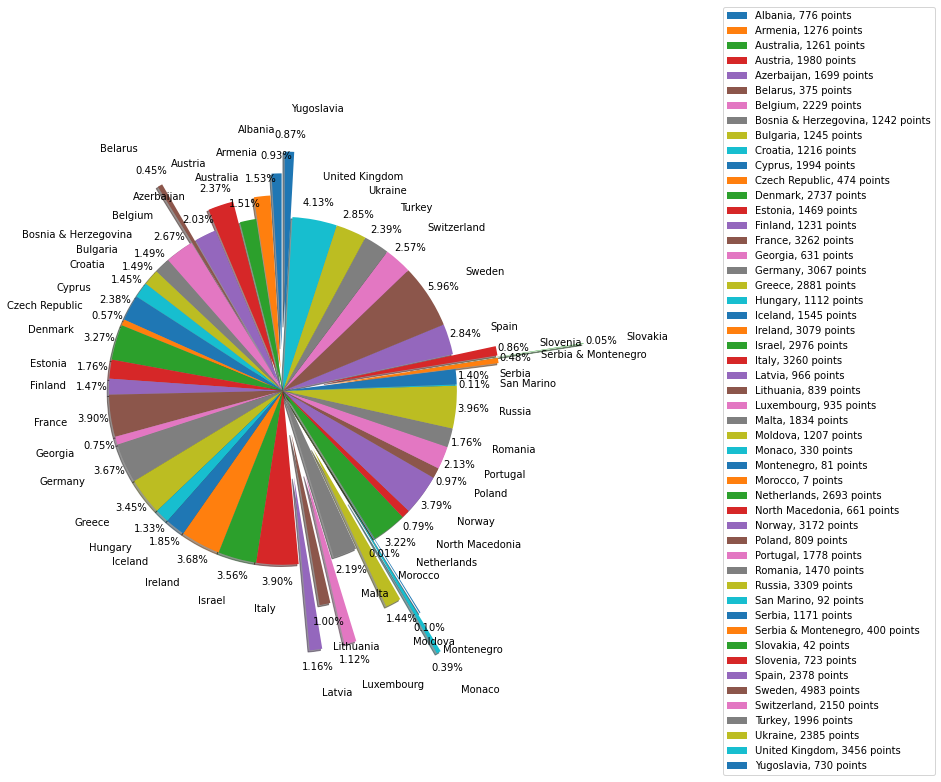

In [26]:
import matplotlib.pyplot as plt

labels = countries_pie
sizes = points_pie.Points
# len(points_pie.Points) == 51
explode = ([0.5,0.25,0,0.25,0,0.75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.5,1,0,0.75,1.5,1,0,0,0,0,0,0,0,0,0,0,0.5,1.5,0.5,0,0,0,0,0,0,0.75])

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=1.1, labeldistance=1.25)
plt.legend(labels=['%s, %1.0f points' % (l, s) for l, s in zip(labels, sizes)], bbox_to_anchor=(2.5, 0.5), loc='center left')

plt.show()

With 83,614 points total, Sweden's 4,983 points puts them at nearly 6% of all points distributed. Sweden is then followed by the United Kingdom (4.13%), Russia (3,96%), France (3,90%), and Italy (3,90%). Setting everyone else aside as their own category, we have:

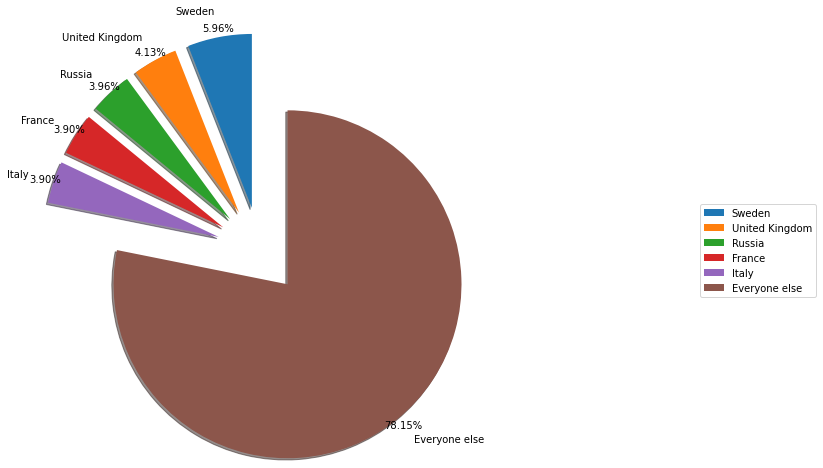

In [27]:
import matplotlib.pyplot as plt

labels = ['Sweden', 'United Kingdom', 'Russia', 'France', 'Italy', 'Everyone else']
sizes = [4983, 3456, 3309, 3262, 3260, 65344]
explode = (0.5, 0.5, 0.5, 0.5, 0.5, 0.5)

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=1.05, labeldistance=1.15)
plt.legend(labels, bbox_to_anchor=(2.5, 0.5), loc='center left')

plt.show()

We could also do this in reverse and just have the countries with the lowest points as well:

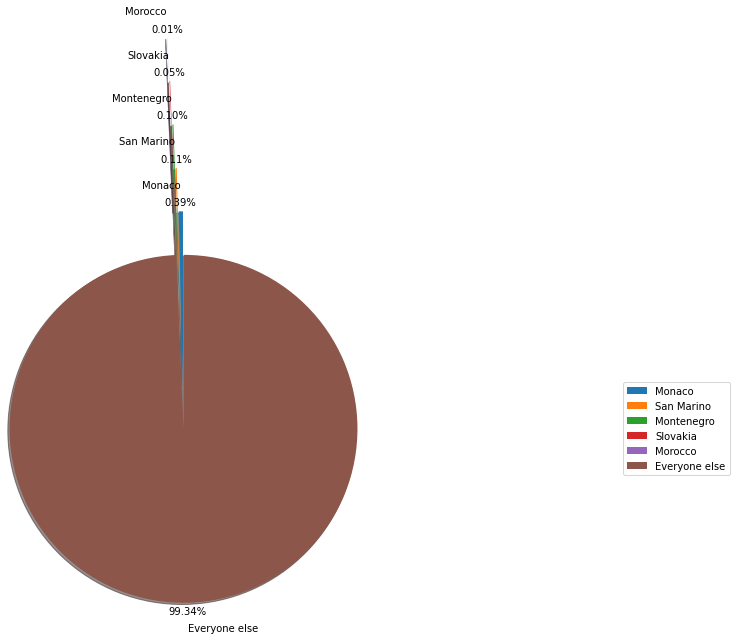

In [28]:
import matplotlib.pyplot as plt

labels = ['Monaco', 'San Marino', 'Montenegro', 'Slovakia', 'Morocco', 'Everyone else']
sizes = [330, 92, 81, 42, 7, 83062]
explode = (0.5, 1, 1.5, 2, 2.5, 0)

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=1.05, labeldistance=1.15)
plt.legend(labels, bbox_to_anchor=(2.5, 0.5), loc='center left')

plt.show()

The bottom 5 countries only make up 0.66% of all points distriubtions.

### Who were the winners for each year?

Let's build a table that just includes the years, the countries, and their points. 

In [29]:
finalpoints = eurovisionfinal.groupby(['Year','tCountry']).transform('sum')['Points']

In [30]:
table = eurovisionfinal
table.insert(12,'Final Points', finalpoints)
table

,Year,(semi-) final,Edition,Jury or Televoting,From country,To country,Points,Duplicate,Decade,Century,fCountry,tCountry,Final Points
0,1975,f,1975f,J,Belgium,Belgium,0,x,1970,1900,Belgium,Belgium,17
1,1975,f,1975f,J,Belgium,Finland,0,nan,1970,1900,Belgium,Finland,74
2,1975,f,1975f,J,Belgium,France,2,nan,1970,1900,Belgium,France,91
3,1975,f,1975f,J,Belgium,Germany,0,nan,1970,1900,Belgium,Germany,15
4,1975,f,1975f,J,Belgium,Ireland,12,nan,1970,1900,Belgium,Ireland,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49827,2019,f,2019f,J,Belarus,Greece,0,nan,2010,2000,Belarus,Greece,71
49828,2019,f,2019f,J,Belarus,Germany,8,nan,2010,2000,Belarus,Germany,32
49829,2019,f,2019f,J,Belarus,Belarus,0,x,2010,2000,Belarus,Belarus,38
49830,2019,f,2019f,J,Belarus,The Netherlands,0,nan,2010,2000,Belarus,Netherlands,492


Now to delete the extra columns.

In [31]:
del table['(semi-) final']
del table['Edition']
del table['Jury or Televoting']
del table['From country']
del table['To country']
del table['Points']
del table['Duplicate']
del table['Decade']
del table['Century']
del table['fCountry']
table

,Year,tCountry,Final Points
0,1975,Belgium,17
1,1975,Finland,74
2,1975,France,91
3,1975,Germany,15
4,1975,Ireland,68
...,...,...,...
49827,2019,Greece,71
49828,2019,Germany,32
49829,2019,Belarus,38
49830,2019,Netherlands,492


Now we have to drop the duplicates.

In [32]:
table = table.sort_values(['Year','Final Points'],ascending=[True,False]).drop_duplicates()
table

,Year,tCountry,Final Points
15,1975,Netherlands,152
17,1975,United Kingdom,138
6,1975,Italy,115
2,1975,France,91
7,1975,Luxembourg,84
...,...,...,...
47066,2019,Spain,58
47067,2019,Israel,46
47088,2019,Belarus,38
47087,2019,Germany,32


With a cleaned table, we can pluck out the winners of each year by the country with the most amount of points.

In [33]:
Blank = []
Yearly = table['Year'].unique()
Country = []
Points = []

for i in range(len(Yearly)):
    Country.append(table.loc[(table['Year'] == Yearly[i])].head(1)['tCountry'].values)
    Points.append(table.loc[(table['Year'] == Yearly[i])].head(1)['Final Points'].values)
    
Winners = pd.DataFrame(Blank)
Winners.insert(0, 'Year', Yearly)
Winners.insert(1, 'Country', Country)
Winners.insert(2, 'Points', Points)

Winners['Country'] = Winners['Country'].str[0]
Winners['Points'] = Winners['Points'].str[0]

Winners

,Year,Country,Points
0,1975,Netherlands,152
1,1976,United Kingdom,164
2,1977,France,136
3,1978,Israel,157
4,1979,Israel,125
5,1980,Ireland,143
6,1981,United Kingdom,136
7,1982,Germany,161
8,1983,Luxembourg,142
9,1984,Sweden,145


This gives us a concise table of just countries and points.

### Who have won the most Eurovisions?

In [34]:
Winners.groupby(['Country']).count().sort_values('Points',ascending=False)

,Year,Points
Country,,
Ireland,6,6
Israel,4,4
Sweden,4,4
United Kingdom,3,3
Norway,3,3
Denmark,2,2
Ukraine,2,2
France,2,2
Germany,2,2


<b>Ireland!</b> The island country has topped event 6 times! They are followed by Israel and Sweden who each have 4. The United Kingdom and Norway each have 3, and Denmark, Ukraine, France, Germany, and the Netherlands each have 2. Given Ukraine is newly independent in 1991, their already 2 victories might make them the most impressive country of the group.

### What is Ireland's win percentage?

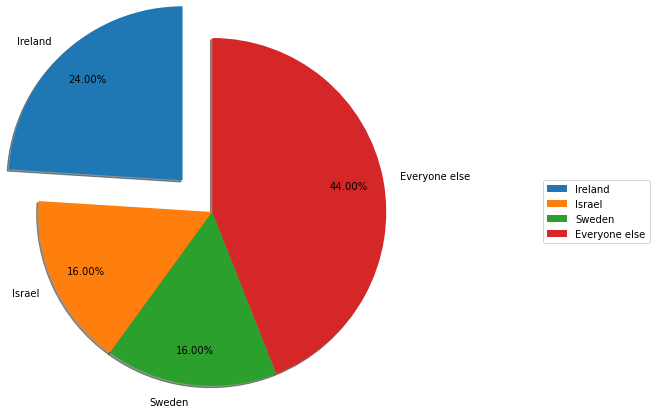

In [35]:
import matplotlib.pyplot as plt

labels = ['Ireland', 'Israel', 'Sweden', 'Everyone else']
sizes = [6, 4, 4, 11]
explode = (0.5, 0, 0, 0)

plt.pie(sizes, labels=labels, explode=explode, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels, bbox_to_anchor=(2, 0.5), loc='center left')

plt.show()

24%! That's almost a quarter!

### Which years did Ireland win it and how many points did they get?

In [36]:
Winners.loc[(Winners['Country'] == 'Ireland')]

,Year,Country,Points
5,1980,Ireland,143
12,1987,Ireland,172
17,1992,Ireland,155
18,1993,Ireland,187
19,1994,Ireland,226
21,1996,Ireland,162


This would mean Ireland's dominance was actually during the 80s and 90s rather throughout the decades. At 226 points in 1994, that would be Ireland's best performance.

### How does Ireland's 1994 victory compare to every other?

In [37]:
Winners.sort_values('Points',ascending=False)

,Year,Country,Points
42,2017,Portugal,758
41,2016,Ukraine,534
43,2018,Israel,529
44,2019,Netherlands,492
34,2009,Norway,387
37,2012,Sweden,372
40,2015,Sweden,365
31,2006,Finland,292
39,2014,Austria,290
38,2013,Denmark,281


Only 17th.

### Who were the runners-up for each year?

In [38]:
Blank = []
Yearly = table['Year'].unique()
Country = []
Points = []

for i in range(len(Yearly)):
    Country.append(table.loc[(table['Year'] == Yearly[i])].head(2)['tCountry'].values)
    Points.append(table.loc[(table['Year'] == Yearly[i])].head(2)['Final Points'].values)
    
Runnersup = pd.DataFrame(Blank)
Runnersup.insert(0, 'Year', Yearly)
Runnersup.insert(1, 'Country', Country)
Runnersup.insert(2, 'Points', Points)

Runnersup['Country'] = Runnersup['Country'].str[1]
Runnersup['Points'] = Runnersup['Points'].str[1]

Runnersup

,Year,Country,Points
0,1975,United Kingdom,138
1,1976,France,147
2,1977,United Kingdom,121
3,1978,Belgium,125
4,1979,Spain,116
5,1980,Germany,128
6,1981,Germany,132
7,1982,Israel,100
8,1983,Israel,136
9,1984,Ireland,137


This gives us another concise table of just runners-ups.

### Who have lost the most Eurovisions?

In [39]:
Runnersup.groupby(['Country']).count().sort_values('Points',ascending=False)

,Year,Points
Country,,
United Kingdom,7,7
Russia,4,4
Germany,4,4
Ireland,2,2
Ukraine,2,2
Spain,2,2
Italy,2,2
Israel,2,2
Malta,2,2


<b>The United Kindgom!</b> At a total of 7 times, the United Kingdom takes pole position at finishing as runners-up. Right after them are Germany and Russia, who each have finished as runners-up 4 times.

### What is the United Kingdom's loss percentage?

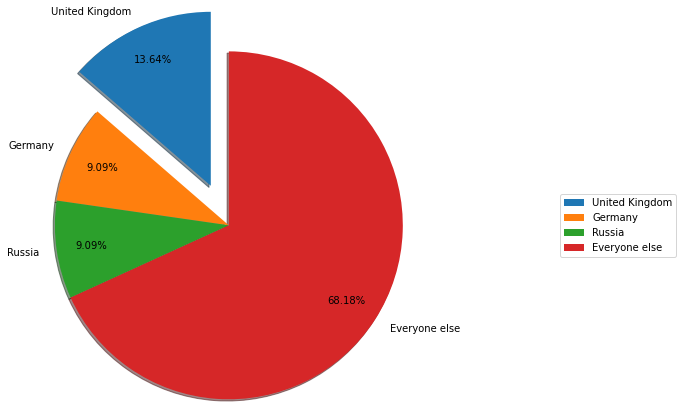

In [40]:
import matplotlib.pyplot as plt

labels = ['United Kingdom', 'Germany', 'Russia', 'Everyone else']
sizes = [6, 4, 4, 30]
explode = (0.5, 0, 0, 0)

plt.pie(sizes, labels=labels, explode=explode, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels, bbox_to_anchor=(2, 0.5), loc='center left')

plt.show()

13.64%. That's over 4.5% more then either Germany or Russia.

### Which years did the United Kingdom lost it and how many points did they get?

In [41]:
Runnersup.loc[(Runnersup['Country'] == 'United Kingdom')]

,Year,Country,Points
0,1975,United Kingdom,138
2,1977,United Kingdom,121
13,1988,United Kingdom,136
14,1989,United Kingdom,130
17,1992,United Kingdom,139
18,1993,United Kingdom,164
23,1998,United Kingdom,166


The United Kingdom's losses are throughout the decades. The good news? It has stopped after the 1990s. The bad news? The United Kingdom has also failed to partake in any finals in the new millennia. At 166 points in 1998, the United Kingdom could've won a few in the years before then.

### How does the United Kingdom's 1998 defeat compare to every other?

In [42]:
Runnersup.sort_values('Points',ascending=False)

,Year,Country,Points
42,2017,Bulgaria,615
41,2016,Australia,511
44,2019,Italy,461
43,2018,Cyprus,436
40,2015,Russia,303
29,2004,Serbia & Montenegro,263
37,2012,Russia,259
31,2006,Russia,248
39,2014,Netherlands,238
32,2007,Ukraine,235


Only 18th.

### How do the winners and runners-up compare in points difference?

Since we already have the tables for winners and runners-up, we could just combine them to form a new table.

In [43]:
difference = Winners
difference['rPoints'] = Runnersup['Points']
difference = difference.rename(columns={'Points':'wPoints'})
difference

,Year,Country,wPoints,rPoints
0,1975,Netherlands,152,138
1,1976,United Kingdom,164,147
2,1977,France,136,121
3,1978,Israel,157,125
4,1979,Israel,125,116
5,1980,Ireland,143,128
6,1981,United Kingdom,136,132
7,1982,Germany,161,100
8,1983,Luxembourg,142,136
9,1984,Sweden,145,137


In [44]:
difference['wPoints'] = pd.to_numeric(difference['wPoints'])
difference['rPoints'] = pd.to_numeric(difference['rPoints'])
difference['Difference'] = difference['wPoints'] - difference['rPoints']
difference.sort_values('Difference',ascending=False)

,Year,Country,wPoints,rPoints,Difference
34,2009,Norway,387,218,169
42,2017,Portugal,758,615,143
37,2012,Sweden,372,259,113
43,2018,Israel,529,436,93
35,2010,Germany,246,170,76
22,1997,United Kingdom,227,157,70
40,2015,Sweden,365,303,62
7,1982,Germany,161,100,61
19,1994,Ireland,226,166,60
39,2014,Austria,290,238,52


Norway's 2009 win by 169 points put them at the top of the list, while the 1991 edition actually had a tie at the top. <b>Sweden</b> is the actual winner, but if it was by today's rules, France would win it instead.

### What is the percentage breakdown of victories by points differences?

We will need another column that rounds down the points differences by the tens and sorts it by its occurences.

In [45]:
difference['Category'] = difference['Difference'].astype(str).str[0:-1]+'0'
difference

,Year,Country,wPoints,rPoints,Difference,Category
0,1975,Netherlands,152,138,14,10
1,1976,United Kingdom,164,147,17,10
2,1977,France,136,121,15,10
3,1978,Israel,157,125,32,30
4,1979,Israel,125,116,9,0
5,1980,Ireland,143,128,15,10
6,1981,United Kingdom,136,132,4,0
7,1982,Germany,161,100,61,60
8,1983,Luxembourg,142,136,6,0
9,1984,Sweden,145,137,8,0


In [46]:
points_difference_pie = difference.groupby(['Category']).count().sort_values('Country',ascending=False)
points_difference_pie

,Year,Country,wPoints,rPoints,Difference
Category,,,,,
10,10,10,10,10,10
0,9,9,9,9,9
30,7,7,7,7,7
40,5,5,5,5,5
20,4,4,4,4,4
60,3,3,3,3,3
70,2,2,2,2,2
110,1,1,1,1,1
140,1,1,1,1,1


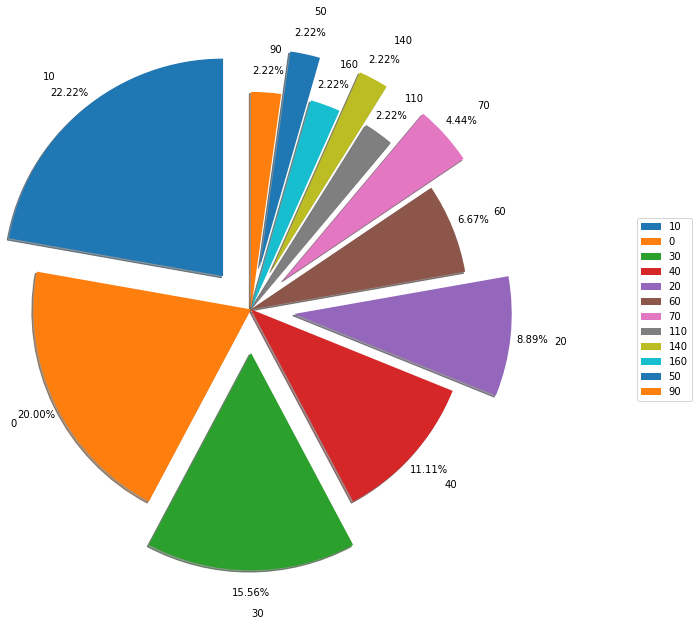

In [47]:
import matplotlib.pyplot as plt

labels = ['10','0','30','40','20','60','70','110','140','160','50','90']
sizes = [10, 9, 7, 5, 4, 3, 2, 1, 1, 1, 1, 1]
explode = (0.5, 0, 0.5, 0, 0.5, 0, 0.5, 0, 0.5, 0, 0.5, 0)

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2.5, pctdistance=1.1, labeldistance=1.2)
plt.legend(labels, bbox_to_anchor=(2.25, 0.5), loc='center left')

plt.show()

Quick summary:<br>
1) It is expected the larger the point differentials, the rarer it is. <br>
2) The categories are largely in order except for a few place swaps. <br>
3) The only noticable exception is 50+ point victories, which only happened once.

### Is there a pattern of points assigning in favour or against other countries?

This question really comes down to if certain countries have more of an affinity (or enmity) towards other countries. Let's set up a new data frame that does just that:

In [48]:
sweden_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Sweden']
sweden_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Denmark,289
Norway,286
Ireland,223
Iceland,190
Finland,179


Looking just at Sweden, we see that the Swedes share quite the affinity with their neighbours the Danes and the Norwegians, giving them 289 and 286 points respectively throughout the entirety of the competition. Let's see if the feeling is mutual from the Danes and the Norwegians.

In [49]:
denmark_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Denmark']
denmark_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Sweden,437
Norway,269
Germany,191
Netherlands,188
Ireland,187


In [50]:
norway_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Norway']
norway_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Sweden,416
Denmark,291
Ireland,179
Iceland,167
Netherlands,162


It is! Both the Danes and the Norwegians give the Swedes back first and each other second! Somehow, Ireland appears on everyone's list here.

### What about the Balkans?

Let's start with Serbia...

In [51]:
serbia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Serbia']
serbia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(10)

,Points
tCountry,
Hungary,156
North Macedonia,135
Russia,100
Slovenia,97
Croatia,89
Ukraine,87
Bosnia & Herzegovina,78
Bulgaria,76
Greece,72


In [52]:
serbia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Serbia']
serbia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).tail(10)

,Points
tCountry,
Poland,7
Slovakia,7
Finland,7
Latvia,6
San Marino,5
Ireland,3
Turkey,3
Spain,2
Serbia,0


With the exception of Sweden, it looks like Serbia likes to stick to mostly either their neighbours or within the Slavic group. The exceptions? <b>Poland</b> and <b>Slovakia</b>. Does Bosnia and Croatia feel the same way?

In [53]:
croatia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Croatia']
croatia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(10)

,Points
tCountry,
Bosnia & Herzegovina,194
North Macedonia,157
Serbia,156
Slovenia,135
Russia,113
Malta,113
Hungary,112
Albania,99
Cyprus,87


In [54]:
croatia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Croatia']
croatia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).tail(10)

,Points
tCountry,
Georgia,16
Belgium,15
Poland,14
Armenia,12
Slovakia,8
San Marino,3
Andorra,2
Croatia,0
Monaco,0


In [55]:
bosnia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Bosnia & Herzegovina']
bosnia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(10)

,Points
tCountry,
Croatia,176
Turkey,133
North Macedonia,114
Serbia,110
Slovenia,110
Sweden,74
Malta,68
Greece,63
France,59


In [56]:
bosnia_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Bosnia & Herzegovina']
bosnia_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).tail(10)

,Points
tCountry,
Switzerland,8
Belarus,8
Latvia,5
Georgia,5
Lithuania,4
Cyprus,2
Monaco,0
Andorra,0
Luxembourg,0


Largely? Yes.

### How neutral are Austria and Switzerland here?

While Switzerland is known to be permanently neutral, so is Austria, something that isn't that well know. Let's see if there's a specific pattern to their points giving:

In [57]:
switzerland_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Switzerland']
switzerland_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Ireland,197
Sweden,190
Israel,186
Portugal,169
Albania,160


In [58]:
austria_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Austria']
austria_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(5)

,Points
tCountry,
Ireland,196
Sweden,187
United Kingdom,168
Netherlands,168
Switzerland,159


Interestingly enough, Switzerland's three language are German, French, and Italian, yet neither three countries make it to their list, nor do any other political entities that have those languages as their main language (i.e. German: Luxembourg; French: Monaco, Italian: San Marino).

As for the Austrians, they give points to all countries that are in the northern half of the continent, but that's about it. While they have their neighbours Switzerland on the list, everyone else lie elsewhere.

So are they neutral in how they give their points? There's definitely an argument for it...

### Is there a reason why the Irish are topping everyone's list so far?

In [59]:
ireland_giving_points = eurovisiondata.loc[(eurovisiondata['fCountry']) == 'Ireland']
ireland_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False).head(25)

,Points
tCountry,
Sweden,223
United Kingdom,219
Norway,212
Denmark,195
Lithuania,194
Netherlands,178
Belgium,148
Germany,148
Israel,146


It looks like the Irish are generous as 18 countries have gotten at least 100 points from them and three more (Finland, Italy, and Poland) are within 10 points from joining that club.

### Does anyone actually hate the Irish?

In [60]:
ireland_deep_dive = eurovisiondata.groupby(['tCountry','fCountry']).sum()[1089:1141]
ireland_deep_dive.sort_values('Points',ascending=True)[1:].head(10)

Points
tCountry fCountry                   
Ireland  Georgia                   0
         Morocco                   0
         Serbia & Montenegro       1
         Serbia                    3
         Armenia                   4
         Montenegro                4
         Andorra                   6
         Moldova                   9
         Belarus                  11
         Ukraine                  12

Maybe not actually. All the countries here are relatively newcomers far, far away who probably haven't developed any rapport with the Irish.

### What are the top 10 giving interactions between countries?

In [61]:
eurovisiondata.groupby(['fCountry','tCountry']).sum().sort_values('Points',ascending=False).head(10)

,,Points
fCountry,tCountry,
Cyprus,Greece,467
Greece,Cyprus,448
Denmark,Sweden,437
Norway,Sweden,416
United Kingdom,Ireland,302
Norway,Denmark,291
Sweden,Denmark,289
Iceland,Sweden,288
Finland,Sweden,287


Quick summary: <br>
<b>Best friends?</b> Cyprus and Greece! They have given each other over 400 points throughout the entirety of this competition. <br>
<b>Best mates?</b> Denmark, Norway, and Sweden! Not only they take up 5 of the top 10 interactions, but they also have their neighbours Finland and Iceland also gifting Sweden.

### What are the bottom 10 giving interactions between countries?

The rule is it must be more than 12 points, because countries can only give 12 points at most in a single contest. That means each interaction must accrue more than a single contest's worth of points.

In [62]:
bottom = eurovisiondata.groupby(['fCountry','tCountry']).sum().sort_values('Points',ascending=False)
bottom.loc[(bottom['Points']) > 11].tail(10)

,,Points
fCountry,tCountry,
Hungary,North Macedonia,12
Ukraine,Montenegro,12
Lithuania,Spain,12
Armenia,Australia,12
Ukraine,Ireland,12
Switzerland,Slovenia,12
Morocco,Turkey,12
San Marino,Austria,12
Azerbaijan,Austria,12


It looks like it's between countries that are generally culturally and/or geographically distant from each other.

### Last question: Going back to Ireland, what is the percentage breakdown for points given and points received?

In [63]:
ireland_giving_points.groupby(['tCountry']).sum().sort_values('Points',ascending=False)

,Points
tCountry,
Sweden,223
United Kingdom,219
Norway,212
Denmark,195
Lithuania,194
Netherlands,178
Belgium,148
Germany,148
Israel,146


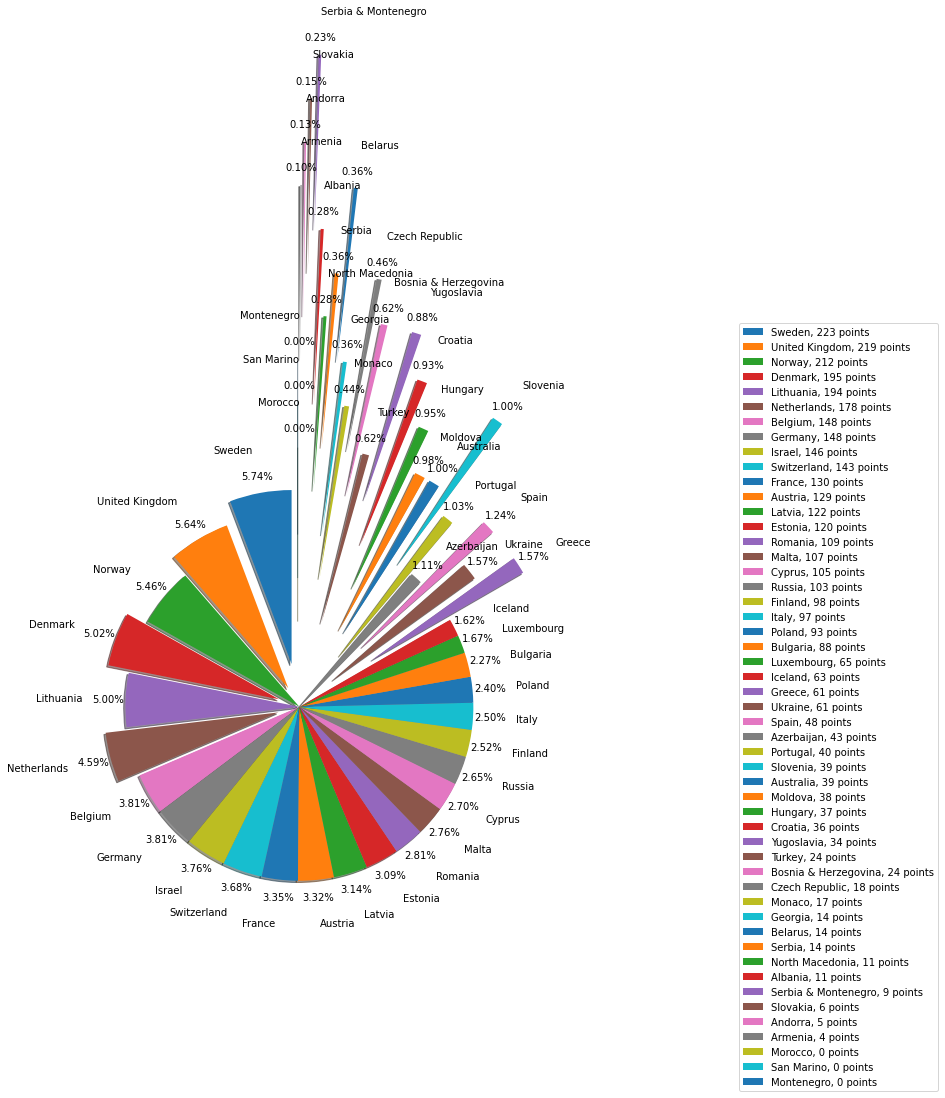

In [64]:
import matplotlib.pyplot as plt

labels = ['Sweden','United Kingdom','Norway','Denmark','Lithuania','Netherlands','Belgium','Germany','Israel','Switzerland','France','Austria','Latvia','Estonia','Romania','Malta','Cyprus','Russia','Finland','Italy','Poland','Bulgaria','Luxembourg','Iceland','Greece','Ukraine','Spain','Azerbaijan','Portugal','Slovenia','Australia','Moldova','Hungary','Croatia','Yugoslavia','Turkey','Bosnia & Herzegovina','Czech Republic','Monaco','Georgia','Belarus','Serbia','North Macedonia','Albania','Serbia & Montenegro','Slovakia','Andorra','Armenia','Morocco','San Marino','Montenegro']
sizes = [223, 219, 212, 195, 194, 178, 148, 148, 146, 143, 130, 129, 122, 120, 109, 107, 105, 103, 98, 97, 93, 88, 65, 63, 61, 61, 48, 43, 40, 39, 39, 38, 37, 36, 34, 24, 24, 18, 17, 14, 14, 14, 11, 11, 9, 6, 5, 4, 0, 0, 0]
# len(points_pie.Points) == 52
explode = ([0.5,0.25,0,0.25,0,0.25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.5,1,0,0.75,2,1,1,1.5,2,2.5,1,2.5,3,1.5,2,4,3,2.5,3.5,5.5,5,4.5,4,1,1.5,2])

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=1.1, labeldistance=1.25)
plt.legend(labels=['%s, %1.0f points' % (l, s) for l, s in zip(labels, sizes)], bbox_to_anchor=(2.5, 0.5), loc='center left')

plt.show()

In [65]:
ireland_deep_dive.sort_values('Points',ascending=False)

Points
tCountry fCountry                    
Ireland  United Kingdom           302
         Sweden                   223
         Switzerland              197
         Austria                  196
         Denmark                  187
         Norway                   179
         Belgium                  178
         Germany                  159
         Spain                    151
         Netherlands              150
         Finland                  129
         Portugal                 128
         Turkey                   124
         Greece                   108
         Italy                    108
         Cyprus                   103
         France                   102
         Estonia                   96
         Luxembourg                96
         Malta                     94
         Israel                    90
         Lithuania                 86
         Iceland                   82
         Croatia                   70
         Latvia                    55
         Bosnia & Herzegovina      54
         Poland                    53
         Hungary                   48
         Romania                   47
         Slovenia                  44
         Russia                    39
         Yugoslavia                38
         Monaco                    31
         Czech Republic            31
         Slovakia                  27
         San Marino                23
         Albania                   20
         Australia                 19
         Azerbaijan                17
         North Macedonia           16
         Bulgaria                  13
         Ukraine                   12
         Belarus                   11
         Moldova                    9
         Andorra                    6
         Armenia                    4
         Montenegro                 4
         Serbia                     3
         Serbia & Montenegro        1
         Georgia                    0
         Ireland                    0
         Morocco                    0

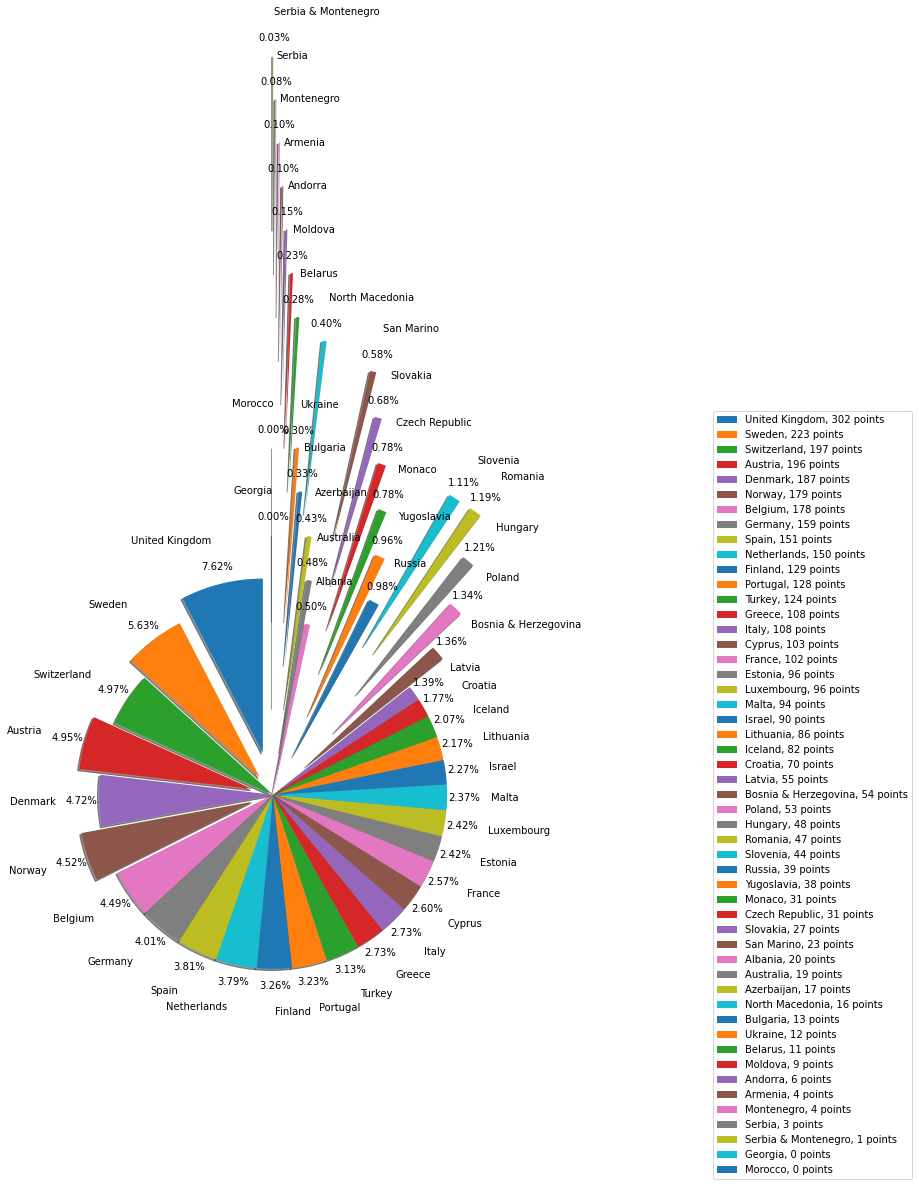

In [66]:
import matplotlib.pyplot as plt

labels = ['United Kingdom','Sweden','Switzerland','Austria','Denmark','Norway','Belgium','Germany','Spain','Netherlands','Finland','Portugal','Turkey','Greece','Italy','Cyprus','France','Estonia','Luxembourg','Malta','Israel','Lithuania','Iceland','Croatia','Latvia','Bosnia & Herzegovina','Poland','Hungary','Romania','Slovenia','Russia','Yugoslavia','Monaco','Czech Republic','Slovakia','San Marino','Albania','Australia','Azerbaijan','North Macedonia','Bulgaria','Ukraine','Belarus','Moldova','Andorra','Armenia','Montenegro','Serbia','Serbia & Montenegro','Georgia','Morocco']
sizes = [302, 223, 197, 196, 187, 179, 178, 159, 151, 150, 129, 128, 124, 108, 108, 103, 102, 96, 96, 94, 90, 86, 82, 70, 55, 54, 53, 48, 47, 44, 39, 38, 31, 31, 27, 23, 20, 19, 17, 16, 13, 12, 11, 9, 6, 4, 4, 3, 1, 0, 0]
# len(points_pie.Points) == 51
explode = ([0.5,0.25,0,0.25,0,0.25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.5,1,1.5,2,2,0.5,1,1.5,2,2.5,3,0,0.5,1,3.25,1.5,2,3.5,4,4.5,5,5.5,6,6.5,1,2])

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', shadow=True, startangle=90, radius=2, pctdistance=1.1, labeldistance=1.25)
plt.legend(labels=['%s, %1.0f points' % (l, s) for l, s in zip(labels, sizes)], bbox_to_anchor=(2.5, 0.5), loc='center left')

plt.show()

There it is! A breakdown for both points given by Ireland and points given to Ireland.

## Credits

Special thanks to:
<br>
https://www.kaggle.com/datagraver/eurovision-song-contest-scores-19752019
<br>
for the original dataset of the Eurovision Song Contest from 1975-2019.

Detailed background can be found here:
<br>
https://en.wikipedia.org/wiki/Eurovision_Song_Contest